# Polygon Radial-Bin Walkthrough (origin TFDS first, coco128 fallback)

This notebook makes the **PolyYOLO radial polygon representation** visible on
**real data**, running the project's **actual** `data_pipeline` code (imported,
not reimplemented).

**Data source — origin dataset first, coco fallback.** The setup cell first tries
to load the **origin training dataset** via TFDS + the repo's own
`PolygonDecoder` (`resample_points=64`, *exactly as training*) — on the cloud this
runs on the **origin dataset** (`cleaner_polygon2026:2.0.0`). If TFDS isn't
available locally it **falls back** to the Ultralytics **coco128-seg** sample
(real images + real polygon annotations) and prints a clear note. **Every
downstream cell works with either source unchanged.**

## The radial format in one picture

Each object's segmentation polygon is re-encoded, **relative to its bounding-box
center**, into **24 angular bins** of **15°** each (`360 / 15 = 24`). Per bin we
store **3 numbers** — so the per-object target is `[24 × 3] = 72` wide
(interleaved `dist, angle-offset, conf` — see `yolo_parser._preprocess_polygons_v2`):

| field | meaning | how it's trained / decoded |
|-------|---------|----------------------------|
| **dist** | radial distance from box center to the bin's representative vertex (the **max-radius** vertex that falls in this 15° wedge) | L2 + softplus regression, masked to occupied bins |
| **angle** (offset) | **sub-bin** offset `(vertex_angle − bin_start)/15 ∈ [0,1)` — *not* a one-hot; recovers the exact vertex angle | BCE on `sigmoid`, masked to occupied bins; decode: `angle = (i + sigmoid)·15°` |
| **conf** | `1.0` if any valid vertex landed in this bin, else `0.0` | BCE — trains the head to **predict emptiness** |

### Why empty bins exist — and why that *helps*

A 15° wedge is **empty** whenever the object's contour simply doesn't extend in
that direction from the box center. This is common and expected:

- **thin-side** — an elongated object (a person, a bottle) has no boundary along
  its *thin* axis at box-center radius, so the side wedges hold no vertex.
- **clipped** — after mosaic/crop an object can sit on the image edge; wedges
  pointing **out of the frame** have no contour there.
- **behind-near-lobe** — a concave / odd shape can have a nearer lobe occluding a
  direction, leaving a wedge empty even though the bounding box covers it.

Empty bins carry **`conf = 0`** targets. That trains the **conf head to predict
emptiness** in those directions. At **decode** time, bins with low conf are
**skipped**, so the reconstructed 24-gon **never hallucinates** a boundary point
where the object has none. Occupied bins give the boundary point **exactly**
(dist + sub-bin offset). So the radial format is *honest about missing
directions* — that is precisely what makes it learnable and robust for thin,
clipped, and concave shapes.

### Arc-length resampling (decode-time)

Stored polygons can be sparse (a rectangle = 4 corners). The repo resamples each
contour to a fixed vertex count by **uniform arc length** at decode
(`parser.resample_points`, default **64**), so points are created **along edges**
— long edges that cross several wedges now populate those wedges. Without this a
4-corner rectangle would only ever fill ≤4 bins (a diamond). **Section 6**
demonstrates exactly this on a real object.

## Setup — origin TFDS first, coco128 fallback

The config cell below names the **origin** dataset (`TFDS_NAME`,
`TFDS_DATA_DIR`). The data-load cell (section 1) **first tries** to load 10 random
examples via `tfds` + the repo's `PolygonDecoder(resample_points=64)` — the exact
decode used in training. **On the cloud this runs on the origin dataset.**

If TFDS can't find the dataset locally (the common case on a laptop), it **falls
back** to **coco128-seg** under `DATA_DIR` and prints a clear note. To fetch
coco128-seg (≈7 MB) for the fallback:

```bash
curl -L -o /Users/sumanth/claude-work/datasets/coco128-seg.zip --create-dirs \
  https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128-seg.zip
cd /Users/sumanth/claude-work/datasets && unzip -q coco128-seg.zip
```

Either way the loader yields the repo's standard **decoded-example dicts**, so
**every downstream cell is source-agnostic**.

In [1]:
import os, sys, math, glob, random

# --- locate repo root so `import data_pipeline...` works from notebooks/ ---
CWD = os.getcwd()
REPO_ROOT = CWD
for _ in range(4):
    if os.path.isdir(os.path.join(REPO_ROOT, "data_pipeline")):
        break
    REPO_ROOT = os.path.dirname(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# === DATA CONFIG ===========================================================
# Origin dataset (loaded FIRST via TFDS + the repo's PolygonDecoder, exactly as
# training). On the cloud TFDS_DATA_DIR holds these and the notebook runs on the
# ORIGIN dataset; locally TFDS is usually absent and we fall back to coco128-seg.
TFDS_DATA_DIR = os.environ.get(
    "TFDS_DATA_DIR", "/group-volume/bot.sumanth/tensorflow_datasets/"
)
TFDS_NAME = os.environ.get("TFDS_NAME", "cleaner_polygon2026:2.0.0")
TFDS_SPLIT = os.environ.get("TFDS_SPLIT", "train")

# coco128-seg fallback location (used only if the TFDS load above fails).
DATA_DIR = os.environ.get("DATA_DIR", "/Users/sumanth/claude-work/datasets/coco128-seg")
IMG_DIR = os.path.join(DATA_DIR, "images", "train2017")
LBL_DIR = os.path.join(DATA_DIR, "labels", "train2017")
# ===========================================================================

SEED = 20260613
random.seed(SEED)
print("repo root     :", REPO_ROOT)
print("TFDS_NAME     :", TFDS_NAME)
print("TFDS_DATA_DIR :", TFDS_DATA_DIR)
print("coco fallback :", DATA_DIR, "(exists)" if os.path.isdir(IMG_DIR) else "(missing)")

repo root     : /Users/sumanth/claude-work/yolov8
TFDS_NAME     : cleaner_polygon2026:2.0.0
TFDS_DATA_DIR : /group-volume/bot.sumanth/tensorflow_datasets/
coco fallback : /Users/sumanth/claude-work/datasets/coco128-seg (exists)


In [2]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib
matplotlib.use("Agg") if False else None  # inline backend in notebook
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw

# --- REAL repo pipeline code (imported, not reimplemented) ---
from data_pipeline.copy_paste import CopyAndPasteModule
from data_pipeline.mosaic import Mosaic
from data_pipeline.yolo_parser import V8ParserExtended
from data_pipeline.batch_color_aug import batch_color_augment
from data_pipeline.augmentations import resample_polygons
from data_pipeline.tfds_decoders import PolygonDecoder   # the exact training decoder

H = W = 672
LEVELS = ["3", "4", "5"]
STRIDES = {"3": 8, "4": 16, "5": 32}
ANGLE_STEP = 15
N_ANGLES = 360 // ANGLE_STEP   # 24
RESAMPLE = 64                  # parser.resample_points default
print("TensorFlow", tf.__version__, "· TFDS", tfds.version.__version__)

/opt/homebrew/Caskroom/miniconda/base/envs/yolo_tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow 2.15.0 · TFDS 4.9.3


## Inline helpers

Drawing helpers, plus two small **coco128 fallback** loaders that build the
repo's standard *decoded-example* dict (matching
`data_pipeline/tfds_decoders.py:PolygonDecoder` output schema) when TFDS is not
available. For the **TFDS / origin** path the repo's `PolygonDecoder` produces
that same dict directly, so both paths feed identical downstream code. (For coco,
the bbox per object is derived as the polygon min/max yxyx-normalized and `dists`
are random `U[0.5, 10.0]` to exercise the distance channel.)

In [3]:
def list_examples(data_dir=DATA_DIR):
    stems = []
    for ip in sorted(glob.glob(os.path.join(data_dir, "images", "train2017", "*.jpg"))):
        st = os.path.splitext(os.path.basename(ip))[0]
        lp = os.path.join(data_dir, "labels", "train2017", st + ".txt")
        if os.path.exists(lp) and os.path.getsize(lp) > 0:
            stems.append(st)
    return stems

def _parse_label(path):
    classes, polys = [], []
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) < 7:
                continue
            cls = int(float(p[0]))
            coords = np.asarray(p[1:], dtype=np.float32)
            coords = coords[:(len(coords) // 2) * 2]
            xy = coords.reshape(-1, 2)
            if xy.shape[0] < 3:
                continue
            classes.append(cls); polys.append(xy)
    return classes, polys

def load_example(stem, data_dir=DATA_DIR, seed=None, dist_range=(0.5, 10.0)):
    """coco128 FALLBACK: build the repo decoded-example dict for one image stem."""
    img = np.asarray(Image.open(os.path.join(data_dir, "images", "train2017", stem + ".jpg")
                               ).convert("RGB"), dtype=np.uint8)
    Hh, Ww = img.shape[:2]
    classes, polys = _parse_label(os.path.join(data_dir, "labels", "train2017", stem + ".txt"))
    n = len(classes)
    boxes = np.zeros((n, 4), np.float32)
    for i, xy in enumerate(polys):
        x = np.clip(xy[:, 0], 0, 1); y = np.clip(xy[:, 1], 0, 1)
        boxes[i] = [y.min(), x.min(), y.max(), x.max()]
    maxc = max([xy.shape[0] * 2 for xy in polys] or [2])
    parr = np.full((n, maxc), -1.0, np.float32)
    for i, xy in enumerate(polys):
        flat = xy.reshape(-1); parr[i, :flat.shape[0]] = flat
    rng = np.random.default_rng(seed if seed is not None else (hash(stem) & 0xFFFFFFFF))
    dists = rng.uniform(*dist_range, size=n).astype(np.float32)
    areas = ((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])).astype(np.float32)
    return {
        "image": tf.constant(img, tf.uint8),
        "source_id": tf.constant(stem),
        "height": tf.constant(Hh, tf.int32), "width": tf.constant(Ww, tf.int32),
        "groundtruth_boxes": tf.constant(boxes, tf.float32),
        "groundtruth_classes": tf.constant(np.asarray(classes, np.int64)),
        "groundtruth_polygons": tf.constant(parr, tf.float32),
        "groundtruth_is_crowd": tf.constant(np.zeros(n, bool)),
        "groundtruth_area": tf.constant(areas, tf.float32),
        "groundtruth_dontcare": tf.constant(np.zeros(n, np.int64)),
        "groundtruth_dists": tf.constant(dists, tf.float32),
    }

def np_(t):
    return t.numpy() if hasattr(t, "numpy") else np.asarray(t)

def poly_flat_to_xy(pf):
    pts = np.asarray(pf).reshape(-1, 2)
    return pts[pts[:, 0] > -1.0]

def pre_resize(ex):
    img = tf.cast(tf.image.resize(tf.cast(ex["image"], tf.float32), [H, W], "bilinear"), tf.uint8)
    img.set_shape([H, W, 3])
    return {**ex, "image": img}

def resample_decoded(ex, k=RESAMPLE):
    return {**ex, "groundtruth_polygons": resample_polygons(ex["groundtruth_polygons"], k)}

def cp_source_from_example(ex, obj_index=0):
    """SOURCE-AGNOSTIC copy-paste source: cut object `obj_index` out of a DECODED
    example dict (TFDS or coco) using its polygon as the alpha mask, producing the
    cleaner_copy_paste:1.0.0-style RGBA dict CopyAndPasteModule consumes."""
    img = np_(ex["image"]); Hh, Ww = img.shape[:2]
    xy = poly_flat_to_xy(np_(ex["groundtruth_polygons"])[obj_index])  # [V,2] normalized
    px = np.clip(xy[:, 0] * Ww, 0, Ww - 1); py = np.clip(xy[:, 1] * Hh, 0, Hh - 1)
    x0, x1 = int(px.min()), max(int(np.ceil(px.max())), int(px.min()) + 1)
    y0, y1 = int(py.min()), max(int(np.ceil(py.max())), int(py.min()) + 1)
    crop = img[y0:y1, x0:x1]; ch, cw = crop.shape[:2]
    mim = Image.new("L", (cw, ch), 0)
    ImageDraw.Draw(mim).polygon([(float(px[i] - x0), float(py[i] - y0)) for i in range(len(px))], fill=255)
    alpha = np.asarray(mim, np.uint8)[:, :, None]
    rgba = np.concatenate([crop, alpha], -1).astype(np.uint8)
    cxy = np.stack([(px - x0) / max(cw, 1), (py - y0) / max(ch, 1)], -1).astype(np.float32)
    obox = np.array([cxy[:, 1].min(), cxy[:, 0].min(), cxy[:, 1].max(), cxy[:, 0].max()], np.float32)
    label = int(np_(ex["groundtruth_classes"])[obj_index])
    return {
        "image": tf.constant(rgba, tf.uint8), "image/id": tf.constant(0, tf.int64),
        "orig_bbox": tf.constant(obox, tf.float32),
        "label": tf.constant(label, tf.int64),
        "points": tf.constant(cxy.reshape(-1), tf.float32), "obj_id": tf.constant(0, tf.int64),
    }

print("helpers ready")

helpers ready


In [4]:
def decode_target(box_yxyx, t72):
    """Decode a [72] radial target → vertices, using the repo decode rule."""
    cy = (box_yxyx[0] + box_yxyx[2]) / 2.0
    cx = (box_yxyx[1] + box_yxyx[3]) / 2.0
    t = t72.reshape(N_ANGLES, 3)
    out = []
    for i in range(N_ANGLES):
        dist, off, conf = float(t[i, 0]), float(t[i, 1]), float(t[i, 2])
        if conf <= 0.5:
            out.append((i, None, None, dist, off, conf)); continue
        ang = math.radians((i + off) * ANGLE_STEP)
        out.append((i, cx + dist * math.cos(ang), cy + dist * math.sin(ang), dist, off, conf))
    return cx, cy, out

def empty_reason(i, box, verts):
    cy = (box[0] + box[2]) / 2; cx = (box[1] + box[3]) / 2
    bh, bw = box[2] - box[0], box[3] - box[1]
    ang = math.radians((i + 0.5) * ANGLE_STEP); dx, dy = math.cos(ang), math.sin(ang)
    def _t(target_x_lo, target_x_hi, target_y_lo, target_y_hi):
        ts = []
        if dx > 1e-6: ts.append((target_x_hi - cx) / dx)
        elif dx < -1e-6: ts.append((target_x_lo - cx) / dx)
        if dy > 1e-6: ts.append((target_y_hi - cy) / dy)
        elif dy < -1e-6: ts.append((target_y_lo - cy) / dy)
        return min([t for t in ts if t > 0], default=1e9)
    t_frame = _t(0, 1, 0, 1)
    t_edge = _t(box[1], box[3], box[0], box[2])
    if t_frame < 0.85 * t_edge: return "clipped"
    if verts.shape[0]:
        vdx = verts[:, 0] - cx; vdy = verts[:, 1] - cy
        vr = np.hypot(vdx, vdy); vang = np.degrees(np.arctan2(vdy, vdx)) % 360
        d = np.abs(((vang - (i + 0.5) * ANGLE_STEP + 180) % 360) - 180)
        near, far = vr[d < 45], vr[d < 90]
        if near.size and far.size and near.min() < 0.6 * far.max():
            return "behind-near-lobe"
    aspect = max(bw, bh) / max(min(bw, bh), 1e-6)
    return "thin-side" if aspect > 1.4 else "no-contour"

def show_stage(image_u8, boxes, polys, title, max_px=800):
    Hh, Ww = image_u8.shape[:2]
    fw = min(max_px, Ww) / 100; fh = fw * Hh / Ww
    fig, ax = plt.subplots(figsize=(fw, fh), dpi=100)
    ax.imshow(image_u8); ax.set_title(title, fontsize=10); ax.axis("off")
    if boxes is not None:
        for b in boxes:
            if (b[2] - b[0]) <= 0 or (b[3] - b[1]) <= 0: continue
            y0, x0, y1, x1 = b[0]*Hh, b[1]*Ww, b[2]*Hh, b[3]*Ww
            ax.plot([x0,x1,x1,x0,x0], [y0,y0,y1,y1,y0], "-", color="yellow", lw=1)
    if polys is not None:
        for pf in polys:
            v = poly_flat_to_xy(pf)
            if v.shape[0] >= 2:
                vx = np.append(v[:,0]*Ww, v[0,0]*Ww); vy = np.append(v[:,1]*Hh, v[0,1]*Hh)
                ax.plot(vx, vy, "-", color="cyan", lw=1, alpha=0.85)
    plt.show()

print("viz ready")

viz ready


## 1. Load + decode 10 random examples — origin TFDS first, coco fallback

We **first try** the origin dataset via `tfds.load(TFDS_NAME, data_dir=TFDS_DATA_DIR)`
mapped through the repo's `PolygonDecoder(resample_points=64)` — *exactly the
training decode* (this mirrors how `01_data_pipeline_debug.ipynb` loads TFDS).
**On the cloud this is the origin dataset.** If that load fails (no TFDS locally),
we **fall back** to coco128-seg and print a clear note. Either way `EXAMPLES` is a
list of 10 pre-resized, resampled decoded-example dicts that every later cell
consumes identically.

NOTE: origin TFDS 'cleaner_polygon2026:2.0.0' not available here (DatasetNotFoundError: Dataset cleaner_polygon2026 not found.
Available datasets:
	- abstract_reasoning
	- accent).
      FALLING BACK to coco128-seg. On the cloud this cell loads the ORIGIN dataset;
      locally it falls back to coco. All downstream cells are unchanged either way.
[fallback] loaded 10 coco128 examples: ['000000000589', '000000000564', '000000000165', '000000000531', '000000000309', '000000000071', '000000000034', '000000000397', '000000000133', '000000000428']

DATA SOURCE : coco128-seg (FALLBACK)
n examples  : 10


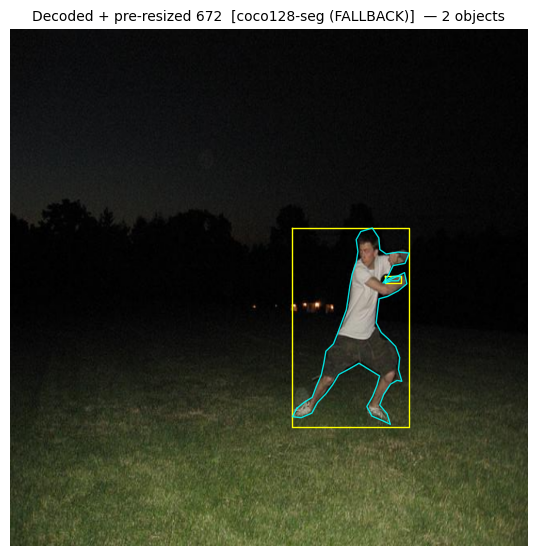

In [5]:
# --- Try the ORIGIN dataset via TFDS + the repo's PolygonDecoder first ---------
tf.random.set_seed(SEED)
EXAMPLES = []        # list of decoded-example dicts (pre-resized + resampled)
SOURCE = None

def _prep_tfds(ex):
    # PolygonDecoder(resample_points=64) already resampled the polygons exactly as
    # training; we only pre-resize the image to 672 for the mosaic stage.
    return pre_resize(ex)

def _prep_coco(stem, seed):
    # coco path: resample at decode time too (mirrors PolygonDecoder default).
    return resample_decoded(pre_resize(load_example(stem, seed=seed)))

try:
    decoder = PolygonDecoder(resample_points=RESAMPLE)            # exactly as training
    ds = tfds.load(TFDS_NAME, split=TFDS_SPLIT, data_dir=TFDS_DATA_DIR,
                   as_supervised=False, download=False)
    ds = ds.map(decoder.decode)
    # take a pool, keep examples that have at least one object, pick 10 (seeded).
    pool = []
    for ex in ds.shuffle(256, seed=SEED).take(60):
        if int(tf.shape(ex["groundtruth_boxes"])[0]) >= 1:
            pool.append(_prep_tfds(ex))
        if len(pool) >= 10:
            break
    if len(pool) < 10:
        raise RuntimeError(f"only {len(pool)} usable TFDS examples found")
    EXAMPLES = pool[:10]
    SOURCE = f"tfds (ORIGIN dataset: {TFDS_NAME})"
    print(f"[origin] loaded 10 examples from TFDS '{TFDS_NAME}' @ {TFDS_DATA_DIR}")
except Exception as e:
    # --- FALLBACK: coco128-seg ---------------------------------------------------
    print("=" * 78)
    print(f"NOTE: origin TFDS '{TFDS_NAME}' not available here ({type(e).__name__}: {str(e)[:90]}).")
    print("      FALLING BACK to coco128-seg. On the cloud this cell loads the ORIGIN dataset;")
    print("      locally it falls back to coco. All downstream cells are unchanged either way.")
    print("=" * 78)
    assert os.path.isdir(IMG_DIR), (
        f"coco128-seg fallback not found at {DATA_DIR!r}. Fetch it with the curl command "
        f"in the setup section, or set DATA_DIR / a valid TFDS_DATA_DIR.")
    stems = list_examples()
    rng = np.random.default_rng(SEED)
    demo_stems = list(rng.permutation(stems))[:10]
    EXAMPLES = [_prep_coco(st, seed=1 + i) for i, st in enumerate(demo_stems)]
    SOURCE = "coco128-seg (FALLBACK)"
    print(f"[fallback] loaded 10 coco128 examples:", demo_stems)

print("\nDATA SOURCE :", SOURCE)
print("n examples  :", len(EXAMPLES))

# show the first example
ex0 = EXAMPLES[0]
img0 = np_(ex0["image"]); b0 = np_(ex0["groundtruth_boxes"])
p0 = [np_(ex0["groundtruth_polygons"])[i] for i in range(b0.shape[0])]
show_stage(img0, b0, p0, f"Decoded + pre-resized 672  [{SOURCE}]  — {b0.shape[0]} objects")

## 2. Augmentation stages (REAL pipeline order)

`input_reader.build_train` order: pre-resize 672 → **copy-paste** → padded_batch(group_size)
→ **mosaic** (both branches) → **V8ParserExtended** parse → **batch_color_augment**.

### 2a. Copy-paste — a real object cut from another image (alpha = polygon mask)

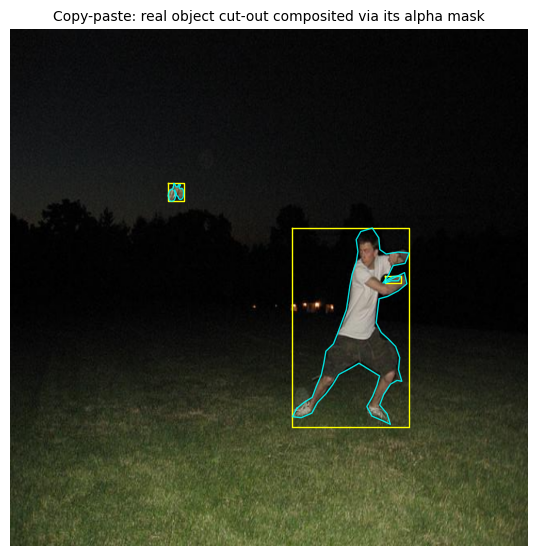

In [6]:
cp_fn = CopyAndPasteModule(prob=1.0).process_fn(is_training=True)   # force paste
src = cp_source_from_example(EXAMPLES[3], obj_index=0)   # cut an object from another example
ex_cp = cp_fn(dict(EXAMPLES[0]), src)
imgc = np_(ex_cp["image"]); bc = np_(ex_cp["groundtruth_boxes"])
pc = [np_(ex_cp["groundtruth_polygons"])[i] for i in range(bc.shape[0])]
show_stage(imgc, bc, pc, "Copy-paste: real object cut-out composited via its alpha mask")

### 2b. Mosaic — both branches (frequency 1.0 = stitch, 0.0 = single warp)

`mosaic_fn` maps a `padded_batch(group_size)` group → `group_size // decodes_per_output` emitted samples. We build a 4-image group with `group_size=4, decodes_per_output=4` → one mosaic (or one single warp) per group, and run the real `Mosaic.mosaic_fn`.

In [ ]:
def stack4(batch_list):
    maxn = max(int(tf.shape(e["groundtruth_boxes"])[0]) for e in batch_list)
    maxc = max(int(tf.shape(e["groundtruth_polygons"])[1]) for e in batch_list)
    out = {}
    spec = {"groundtruth_boxes": (0.0, tf.float32), "groundtruth_classes": (0, tf.int64),
            "groundtruth_is_crowd": (False, tf.bool), "groundtruth_area": (0.0, tf.float32),
            "groundtruth_dontcare": (0, tf.int64), "groundtruth_dists": (0.0, tf.float32)}
    for k, (pv, dt) in spec.items():
        rows = []
        for e in batch_list:
            v = tf.cast(e[k], dt); pad = maxn - int(tf.shape(v)[0])
            rows.append(tf.pad(v, [[0, pad]] + [[0, 0]]*(len(v.shape)-1), constant_values=pv))
        out[k] = tf.stack(rows, 0)
    prows = []
    for e in batch_list:
        v = e["groundtruth_polygons"]
        prows.append(tf.pad(v, [[0, maxn-int(tf.shape(v)[0])], [0, maxc-int(tf.shape(v)[1])]],
                            constant_values=-1.0))
    out["groundtruth_polygons"] = tf.stack(prows, 0)
    for k in ("image", "height", "width", "source_id"):
        out[k] = tf.stack([e[k] for e in batch_list], 0)
    return out

grp_examples = []
for j in range(4):
    e = dict(EXAMPLES[j])
    e = cp_fn(e, cp_source_from_example(EXAMPLES[(j + 1) % 4], 0))  # paste a real object
    grp_examples.append(e)
group = stack4(grp_examples)

for freq, label in [(1.0, "mosaic_frequency=1.0 — 4-image stitch + random_perspective"),
                    (0.0, "mosaic_frequency=0.0 — single-image random_perspective")]:
    tf.random.set_seed(7)
    mos = Mosaic(output_size=[H, W], mosaic_frequency=freq, mixup_frequency=0.0,
                 aug_scale_min=0.4, aug_scale_max=1.9, area_thresh=0.5, with_polygons=True,
                 degrees=10.0, shear=2.0, translate=0.1, mosaic_center=0.25, group_size=4, decodes_per_output=4)
    out4 = mos.mosaic_fn(is_training=True)(group)
    img = np_(out4["image"][0]); bx = np_(out4["groundtruth_boxes"][0])
    pl = [np_(out4["groundtruth_polygons"][0])[i] for i in range(bx.shape[0])]
    show_stage(img, bx, pl, label)

### 2c. Parser — build the radial target, then decode it back

`V8ParserExtended` produces the `[M, 72]` PolyYOLO target. We parse a **single**
(mosaic-off) example, then decode the radial target back to a 24-gon and overlay
it — confirming the encode/decode round-trip on real annotations.

In [ ]:
parser = V8ParserExtended(output_size=[H, W], expanded_strides=STRIDES, levels=LEVELS,
                          angle_step=15, with_polygons=True, random_flip=False,
                          albumentations_frequency=1.0, area_thresh=0.1)
parse_fn = parser.parse_fn(is_training=True)

tf.random.set_seed(7)
mos0 = Mosaic(output_size=[H, W], mosaic_frequency=0.0, mixup_frequency=0.0,
              aug_scale_min=0.95, aug_scale_max=1.05, area_thresh=0.5, with_polygons=True,
              degrees=0.0, shear=0.0, translate=0.0, mosaic_center=0.25, group_size=4, decodes_per_output=4)
single = mos0.mosaic_fn(is_training=True)(group)
sel0 = {k: v[0] for k, v in single.items()}
pimg_t, plbl = parse_fn(sel0)
pimg = np_(pimg_t)
pbox = np_(plbl["bbox"]); ptar = np_(plbl["polygons"]); n_gt = int(np_(plbl["n_gt"]))
print("parsed:", n_gt, "objects;  target shape per obj:", ptar.shape[1], "(= 24 bins x 3)")

rec = []
for j in range(n_gt):
    _, _, dec = decode_target(pbox[j], ptar[j])
    pts = [(d[1], d[2]) for d in dec if d[1] is not None]
    if len(pts) >= 2:
        rec.append(np.array(pts).reshape(-1))
show_stage(pimg, pbox[:n_gt], rec, "Radial target decoded back to 24-gon (cyan) on parsed image")

## 3. Bin-diagnostic figures — the centerpiece

For two chosen objects we draw the **24 fifteen-degree wedge spokes** from the
**box center**: occupied bins shaded **green** (max-dist point marked + sub-bin
offset annotated), empty bins shaded **red** with a one-word reason, and the
decoded 24-gon overlaid on the original polygon.

Read this against the doubt *"how can a bin have no points, and how does that
help?"*: the red wedges are directions the object simply doesn't reach — they get
`conf=0`, so the head learns to predict emptiness and the decoded boundary stays
honest there.

In [9]:
def bin_diagnostic(image_u8, box, poly_flat, target72, title, case_label, caption):
    Hh, Ww = image_u8.shape[:2]
    verts = poly_flat_to_xy(poly_flat)
    cx, cy, dec = decode_target(box, target72)
    t = target72.reshape(N_ANGLES, 3)
    by0, bx0, by1, bx1 = box
    pad = 0.08
    py0, py1 = int(max(0, by0-pad)*Hh), int(min(1, by1+pad)*Hh)
    px0, px1 = int(max(0, bx0-pad)*Ww), int(min(1, bx1+pad)*Ww)
    py1 = max(py1, py0+2); px1 = max(px1, px0+2)
    crop = image_u8[py0:py1, px0:px1]
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 5.4), dpi=100)
    axL.imshow(crop); axL.set_title(title, fontsize=10); axL.axis("off")
    diag = 0.5 * math.hypot(bx1-bx0, by1-by0); R = diag*1.15
    cxp, cyp = cx*Ww-px0, cy*Hh-py0
    for i in range(N_ANGLES):
        a0, a1 = math.radians(i*ANGLE_STEP), math.radians((i+1)*ANGLE_STEP)
        occ = float(t[i, 2]) > 0.5
        arc = np.linspace(a0, a1, 6)
        xs = [cxp] + [(cx+R*math.cos(a))*Ww-px0 for a in arc]
        ys = [cyp] + [(cy+R*math.sin(a))*Hh-py0 for a in arc]
        axL.fill(xs, ys, color="#2ca02c" if occ else "#d62728", alpha=0.16, lw=0)
        sx, sy = (cx+R*math.cos(a0))*Ww-px0, (cy+R*math.sin(a0))*Hh-py0
        axL.plot([cxp, sx], [cyp, sy], color="#888", lw=0.5, alpha=0.6)
        mid = math.radians((i+0.5)*ANGLE_STEP)
        lx, ly = (cx+R*0.72*math.cos(mid))*Ww-px0, (cy+R*0.72*math.sin(mid))*Hh-py0
        if occ:
            _, vx, vy, dist, off, _ = dec[i]
            axL.plot([vx*Ww-px0], [vy*Hh-py0], "o", color="#0b6e0b", ms=4)
            axL.annotate(f"{off:.2f}", (lx, ly), color="#0b3d0b", fontsize=6, ha="center", va="center")
        else:
            axL.annotate(empty_reason(i, box, verts), (lx, ly), color="#7a1414",
                         fontsize=5.5, ha="center", va="center")
    if verts.shape[0] >= 2:
        vx = np.append(verts[:,0]*Ww-px0, verts[0,0]*Ww-px0)
        vy = np.append(verts[:,1]*Hh-py0, verts[0,1]*Hh-py0)
        axL.plot(vx, vy, "-", color="cyan", lw=1.3, alpha=0.9)
    axL.plot([bx0*Ww-px0, bx1*Ww-px0, bx1*Ww-px0, bx0*Ww-px0, bx0*Ww-px0],
             [by0*Hh-py0, by0*Hh-py0, by1*Hh-py0, by1*Hh-py0, by0*Hh-py0], "-", color="yellow", lw=1)
    axL.plot([cxp], [cyp], "+", color="white", ms=10, mew=1.5)
    axL.set_xlim(0, px1-px0); axL.set_ylim(py1-py0, 0)
    axR.imshow(crop); axR.axis("off")
    axR.set_title("decoded 24-gon (green) vs original polygon (cyan)", fontsize=9)
    if verts.shape[0] >= 2:
        axR.plot(vx, vy, "-", color="cyan", lw=1.4, alpha=0.85)
    dp = [(d[1], d[2]) for d in dec if d[1] is not None]
    if len(dp) >= 2:
        dxs = [p[0]*Ww-px0 for p in dp] + [dp[0][0]*Ww-px0]
        dys = [p[1]*Hh-py0 for p in dp] + [dp[0][1]*Hh-py0]
        axR.plot(dxs, dys, "-o", color="#2ca02c", lw=1.4, ms=3, alpha=0.9)
    n_occ = int((t[:, 2] > 0.5).sum())
    axR.text(0.5, -0.06, f"{n_occ}/{N_ANGLES} bins occupied · {N_ANGLES-n_occ} empty (conf=0)",
             transform=axR.transAxes, ha="center", va="top", fontsize=8)
    leg = [mpatches.Patch(color="#2ca02c", alpha=0.3, label="occupied (conf=1)"),
           mpatches.Patch(color="#d62728", alpha=0.3, label="empty (conf=0)")]
    axL.legend(handles=leg, loc="lower center", bbox_to_anchor=(0.5, -0.13), ncol=2,
               fontsize=7, frameon=False)
    fig.suptitle(case_label, fontsize=11, y=1.0, fontweight="bold")
    fig.text(0.5, 0.0, caption, ha="center", va="bottom", fontsize=7.4, wrap=True, color="#333")
    fig.subplots_adjust(top=0.9, bottom=0.16, left=0.02, right=0.98, wspace=0.05)
    plt.show()

CAPTION = ("Empty (red) bins carry conf=0 targets — the conf head learns to PREDICT emptiness there; "
           "at decode those bins are SKIPPED so the 24-gon never hallucinates boundary in directions "
           "the object lacks. Occupied (green) bins regress dist + sub-bin offset, placing the boundary "
           "point exactly.")
print("bin_diagnostic ready")

bin_diagnostic ready


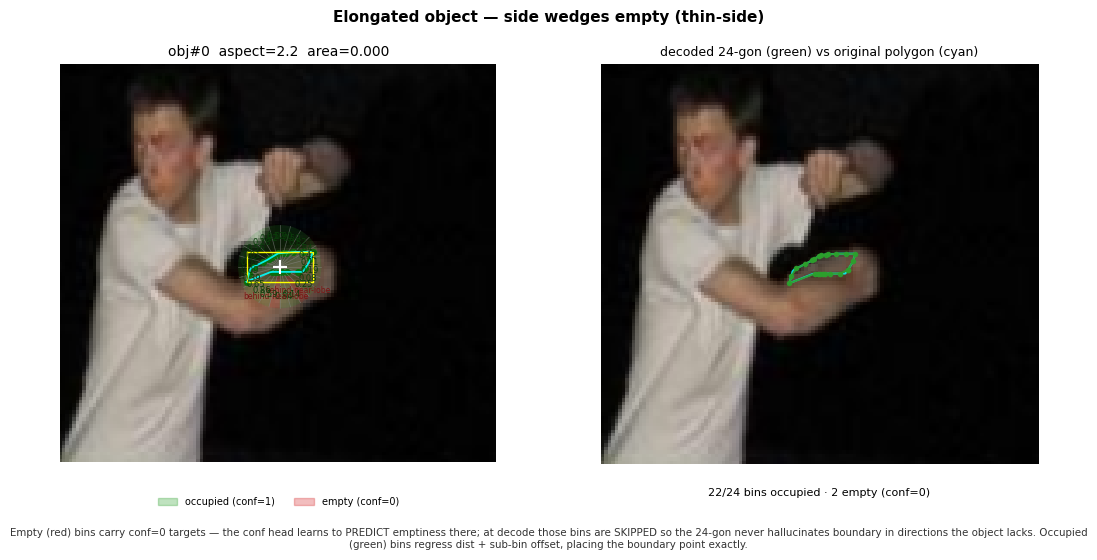

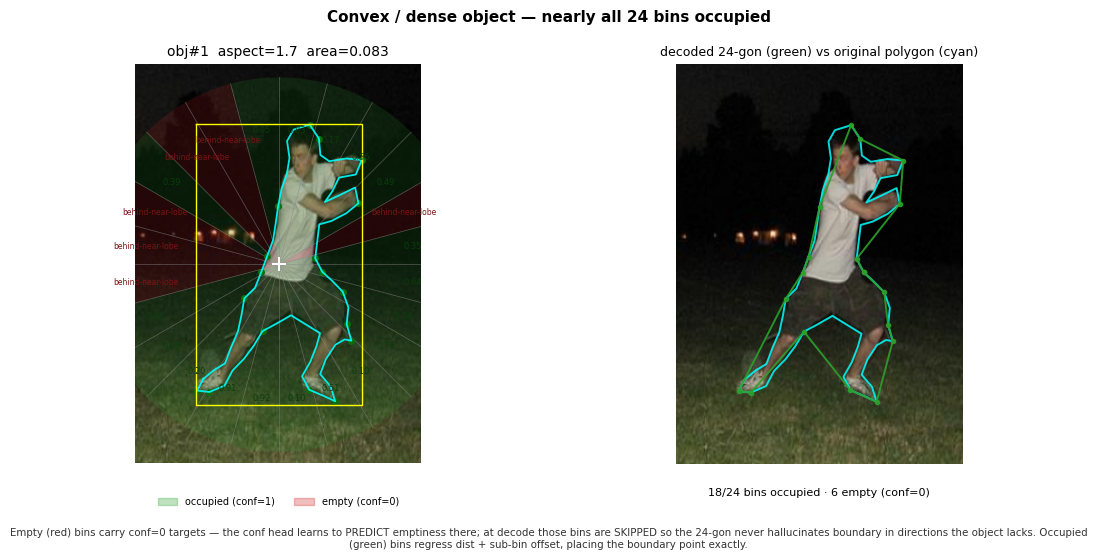

In [10]:
# Use the REAL parser encoder per object, then choose 2 contrasting objects
# from the parsed single image: the most elongated and the most convex/dense.
def encode_one(box, poly_flat):
    t = parser._preprocess_polygons_v2(tf.constant(box[None], tf.float32),
                                       tf.constant(poly_flat[None], tf.float32), 15)
    return np_(t)[0]

# Re-encode per object from the parsed image's raw (pre-radial) geometry in sel0.
raw_boxes = np_(sel0["groundtruth_boxes"])
raw_polys = np_(sel0["groundtruth_polygons"])

cands = []
for i in range(raw_boxes.shape[0]):
    b = raw_boxes[i]; bh, bw = b[2]-b[0], b[3]-b[1]
    if bh <= 0 or bw <= 0: continue
    aspect = max(bw, bh)/max(min(bw, bh), 1e-6)
    cands.append((i, b, raw_polys[i], aspect, bh*bw))

elong = max(cands, key=lambda c: c[3])
convex = max([c for c in cands if c[4] > 0.01] or cands, key=lambda c: -abs(c[3]-1.0))

for tag, c in [("Elongated object — side wedges empty (thin-side)", elong),
               ("Convex / dense object — nearly all 24 bins occupied", convex)]:
    i, b, pf, aspect, area = c
    bin_diagnostic(pimg, b, pf, encode_one(b, pf),
                   title=f"obj#{i}  aspect={aspect:.1f}  area={area:.3f}",
                   case_label=tag, caption=CAPTION)

## 4. Decode-back overlay (full image)

The same encode→decode round-trip across **all** objects of the parsed image —
every cyan original polygon has a tightly matching reconstructed 24-gon.

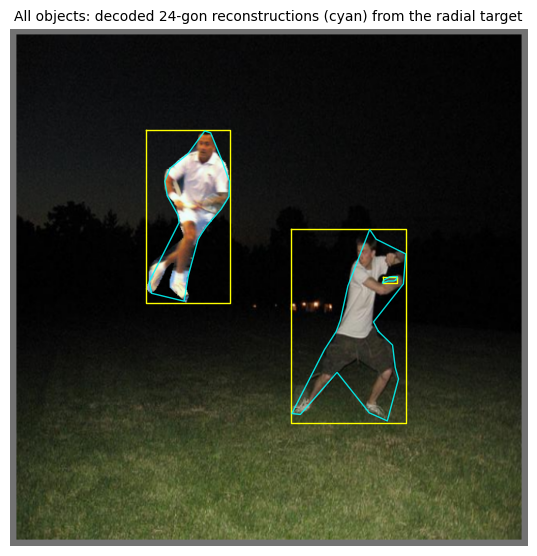

In [11]:
show_stage(pimg, pbox[:n_gt], rec,
           "All objects: decoded 24-gon reconstructions (cyan) from the radial target")

## 5. `batch_color_augment` — per-batch GPU colour pipeline

Final stage: the parser emits **uint8**; HSV jitter + albumentations run once per
**batch** (on the accelerator in `train_step`). Geometry/labels are untouched.

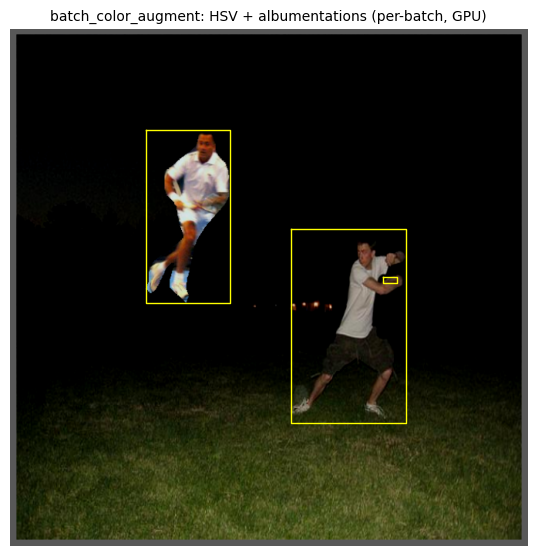

In [12]:
tf.random.set_seed(11)
colored = batch_color_augment(tf.stack([pimg_t], 0), hue=0.015, sat=0.7, val=0.4, albu_freq=1.0)
cimg = (np_(colored[0]) * 255).clip(0, 255).astype(np.uint8)
show_stage(cimg, pbox[:n_gt], None, "batch_color_augment: HSV + albumentations (per-batch, GPU)")

## 6. The 4-point-rectangle case — why arc-length resampling matters

This is the **canonical sparse-annotation** case (absent from dense contours): we
take a clearly-visible real object and **replace its polygon with its 4-corner
bounding rectangle** — exactly mimicking a dataset annotation that carries only 4
points. We then render it **side-by-side** through the **real** code paths:

- **LEFT** — the 4 raw vertices fed straight to
  `V8ParserExtended._preprocess_polygons_v2` (this is what `resample_points=0` /
  the pre-2026-06-13 index-subsampling produced): the 24 wedges, the **≤4 occupied
  bins**, and the **diamond** decode overlay.
- **RIGHT** — the same 4-point rectangle through `resample_polygons(…, 64)`
  (uniform **arc length**) then `_preprocess_polygons_v2`: **~24 occupied bins**,
  sub-bin offsets annotated, and the decode overlay **hugging the rectangle**.

**Takeaway:** *with sparse annotations the radial target only tracks shape because
arc-length resampling interpolates boundary points along edges.* The 4 raw corners
land in ≤4 angular bins (a diamond that ignores the sides); resampling places
points **along the edges**, so the long edges crossing several wedges now populate
them — corner bins carry a fractional sub-bin offset, edge bins saturate toward
`0/1` as they approach the nearest corner, and the decoded 24-gon recovers the
rectangle. (This is figure `prompts/coco_demo_out/bins/8_rectangle_4pt.png`,
inline here.)

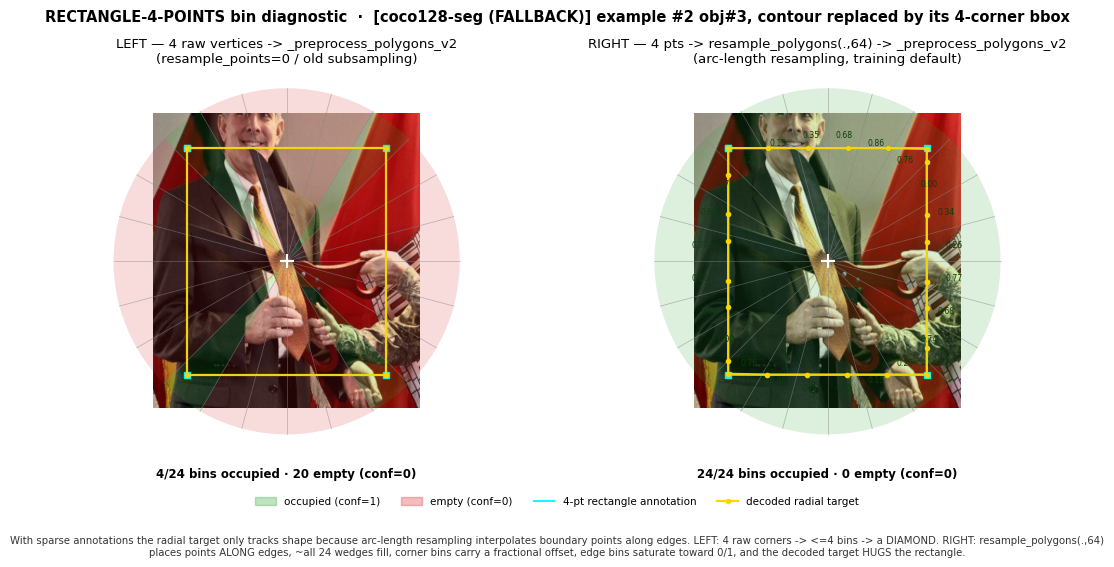

occupied bins  LEFT=4 (diamond)   RIGHT=24 (rectangle)


In [13]:
# --- pick a clearly-visible, well-inset object across the loaded EXAMPLES -------
best = None  # (score, ex_index, obj_index, box)
for ei, ex in enumerate(EXAMPLES):
    boxes = np_(ex["groundtruth_boxes"])
    for oi in range(boxes.shape[0]):
        by0, bx0, by1, bx1 = boxes[oi]
        bw, bh = bx1 - bx0, by1 - by0
        if bw <= 0 or bh <= 0:
            continue
        area = bw * bh
        inset = bx0 > 0.04 and by0 > 0.04 and bx1 < 0.96 and by1 < 0.96
        aspect = max(bw, bh) / max(min(bw, bh), 1e-6)
        if inset and area > 0.04 and aspect < 2.5:
            score = area - 0.05 * aspect      # prefer big + squareish
            if best is None or score > best[0]:
                best = (score, ei, oi, boxes[oi].copy())
if best is None:   # degenerate fallback: just take the largest object anywhere
    areas = [(float((np_(e["groundtruth_boxes"])[k][2]-np_(e["groundtruth_boxes"])[k][0]) *
                    (np_(e["groundtruth_boxes"])[k][3]-np_(e["groundtruth_boxes"])[k][1])), ei, k)
             for ei, e in enumerate(EXAMPLES) for k in range(np_(e["groundtruth_boxes"]).shape[0])]
    a, ei, oi = max(areas)
    best = (a, ei, oi, np_(EXAMPLES[ei]["groundtruth_boxes"])[oi].copy())

_, EI, OI, rbox = best
rect_img = np_(EXAMPLES[EI]["image"])
by0, bx0, by1, bx1 = rbox

# REPLACE the dense contour with its 4-corner bounding rectangle (TL,TR,BR,BL).
rect_xy = np.array([[bx0, by0], [bx1, by0], [bx1, by1], [bx0, by1]], dtype=np.float32)
rect_flat = rect_xy.reshape(-1).astype(np.float32)          # [8] — a 4-point annotation

# LEFT  : 4 raw vertices straight into the parser encoder (resample_points=0 path)
def encode_one(box, poly_flat):
    t = parser._preprocess_polygons_v2(tf.constant(box[None], tf.float32),
                                       tf.constant(poly_flat[None], tf.float32), ANGLE_STEP)
    return np_(t)[0]
target_left = encode_one(rbox, rect_flat)
# RIGHT : same 4 points -> arc-length resample to 64 -> parser encoder (training default)
rect_resampled = np_(resample_polygons(tf.constant(rect_flat[None], tf.float32), RESAMPLE))[0]
target_right = encode_one(rbox, rect_resampled)

n_left = int((target_left.reshape(N_ANGLES, 3)[:, 2] > 0.5).sum())
n_right = int((target_right.reshape(N_ANGLES, 3)[:, 2] > 0.5).sum())

# --- render the side-by-side (same as figure 8) --------------------------------
def _rect_panel(ax, crop, px0, py0, Ww, Hh, box, target, title, annotate):
    cx, cy, dec = decode_target(box, target)
    t = target.reshape(N_ANGLES, 3)
    by0, bx0, by1, bx1 = box
    ax.imshow(crop); ax.set_title(title, fontsize=9.5); ax.axis("off")
    R = 0.5 * math.hypot(bx1 - bx0, by1 - by0) * 1.15
    cxp, cyp = cx * Ww - px0, cy * Hh - py0
    for i in range(N_ANGLES):
        a0, a1 = math.radians(i * ANGLE_STEP), math.radians((i + 1) * ANGLE_STEP)
        occ = float(t[i, 2]) > 0.5
        arc = np.linspace(a0, a1, 6)
        xs = [cxp] + [(cx + R * math.cos(a)) * Ww - px0 for a in arc]
        ys = [cyp] + [(cy + R * math.sin(a)) * Hh - py0 for a in arc]
        ax.fill(xs, ys, color="#2ca02c" if occ else "#d62728", alpha=0.16, lw=0)
        sx, sy = (cx + R * math.cos(a0)) * Ww - px0, (cy + R * math.sin(a0)) * Hh - py0
        ax.plot([cxp, sx], [cyp, sy], color="#888", lw=0.5, alpha=0.6)
        if occ:
            _, vx, vy, dist, off, _ = dec[i]
            ax.plot([vx * Ww - px0], [vy * Hh - py0], "o", color="#0b6e0b", ms=3)
            if annotate:
                mid = math.radians((i + 0.5) * ANGLE_STEP)
                lx, ly = (cx + R * 0.74 * math.cos(mid)) * Ww - px0, (cy + R * 0.74 * math.sin(mid)) * Hh - py0
                ax.annotate(f"{off:.2f}", (lx, ly), color="#0b3d0b", fontsize=5.6, ha="center", va="center")
    rvx = np.append(rect_xy[:, 0] * Ww - px0, rect_xy[0, 0] * Ww - px0)
    rvy = np.append(rect_xy[:, 1] * Hh - py0, rect_xy[0, 1] * Hh - py0)
    ax.plot(rvx, rvy, "-", color="cyan", lw=1.4, alpha=0.9)
    ax.plot(rvx, rvy, "s", color="cyan", ms=4, alpha=0.9)
    dp = [(d[1], d[2]) for d in dec if d[1] is not None]
    if len(dp) >= 2:
        dxs = [p[0] * Ww - px0 for p in dp] + [dp[0][0] * Ww - px0]
        dys = [p[1] * Hh - py0 for p in dp] + [dp[0][1] * Hh - py0]
        ax.plot(dxs, dys, "-o", color="#ffd400", lw=1.6, ms=3, alpha=0.95)
    ax.plot([cxp], [cyp], "+", color="white", ms=10, mew=1.5)
    n_occ = int((t[:, 2] > 0.5).sum())
    ax.text(0.5, -0.04, f"{n_occ}/{N_ANGLES} bins occupied · {N_ANGLES-n_occ} empty (conf=0)",
            transform=ax.transAxes, ha="center", va="top", fontsize=8.5, fontweight="bold")

Hh, Ww = rect_img.shape[:2]
pad = 0.08
py0, py1 = int(max(0, by0 - pad) * Hh), int(min(1, by1 + pad) * Hh)
px0, px1 = int(max(0, bx0 - pad) * Ww), int(min(1, bx1 + pad) * Ww)
py1 = max(py1, py0 + 2); px1 = max(px1, px0 + 2)
crop = rect_img[py0:py1, px0:px1]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 5.6), dpi=100)
_rect_panel(axL, crop, px0, py0, Ww, Hh, rbox, target_left,
            "LEFT — 4 raw vertices -> _preprocess_polygons_v2\n(resample_points=0 / old subsampling)", annotate=False)
_rect_panel(axR, crop, px0, py0, Ww, Hh, rbox, target_right,
            "RIGHT — 4 pts -> resample_polygons(.,64) -> _preprocess_polygons_v2\n(arc-length resampling, training default)", annotate=True)
leg = [mpatches.Patch(color="#2ca02c", alpha=0.3, label="occupied (conf=1)"),
       mpatches.Patch(color="#d62728", alpha=0.3, label="empty (conf=0)"),
       plt.Line2D([0], [0], color="cyan", lw=1.4, label="4-pt rectangle annotation"),
       plt.Line2D([0], [0], color="#ffd400", lw=1.6, marker="o", ms=3, label="decoded radial target")]
fig.legend(handles=leg, loc="lower center", ncol=4, fontsize=7.5, frameon=False, bbox_to_anchor=(0.5, 0.085))
fig.suptitle(f"RECTANGLE-4-POINTS bin diagnostic  ·  [{SOURCE}] example #{EI} obj#{OI}, contour replaced by its 4-corner bbox",
             fontsize=10.5, y=0.99, fontweight="bold")
fig.text(0.5, 0.012,
         "With sparse annotations the radial target only tracks shape because arc-length resampling interpolates boundary points along edges. "
         "LEFT: 4 raw corners -> <=4 bins -> a DIAMOND. RIGHT: resample_polygons(.,64) places points ALONG edges, ~all 24 wedges fill, "
         "corner bins carry a fractional offset, edge bins saturate toward 0/1, and the decoded target HUGS the rectangle.",
         ha="center", va="bottom", fontsize=7.3, wrap=True, color="#333")
fig.subplots_adjust(top=0.88, bottom=0.20, left=0.02, right=0.98, wspace=0.05)
plt.show()
print(f"occupied bins  LEFT={n_left} (diamond)   RIGHT={n_right} (rectangle)")

## Takeaway

The radial 24-bin format encodes each polygon as **dist + sub-bin offset + conf**
per 15° wedge from the box center. **Empty bins are normal and informative**: a
`conf=0` target in a direction the object doesn't reach teaches the conf head to
predict emptiness, and decode **skips** those bins — so the reconstruction is
**honest** about thin, clipped, and concave shapes while occupied bins pin the
boundary exactly. Arc-length resampling ensures even sparse contours populate the
wedges they cross.